# TCN - Horno de Sostenimiento
## Aproximación numérica por medio de G(z)

Kira Pantoja - Raúl Herrera - Patricio Lugo - Sergio Rock

El objetivo principal de este cuaderno de python es generar un predictor temporal por medio del modelo de Temporal Convolutional Network para aprender la dinámica el sistema por medio de datos históricos. Posteriormente, se extrae una función de transferencia lineal en la que por medio de los polinomios A(z) y B(z) podemos extraer los polos y los ceros del sistema.

## 1. Librerías y Configuración

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import scipy.signal as sig
import matplotlib.pyplot as plt


class Config:
    TARGET_COL   = "sensor_temp_main"
    FEATURE_COLS = [
        "heater_power_pct",
        "resistance_current",
        "voltage",
        "aluminum_level_pct",
        "lid_opening_pct",
        "ambient_temp",
        "energy_consumption_kwh",
        "production_draw_rate",
    ]
    USE_AUTOREGRESSIVE = True  # T(t-1)

    # Longitud de historia a atrás a utilizar justificado por EDA. Evaluada en 60,90,120 min
    SEQ_LEN      = 90
    PRED_HORIZON = 1

    # 5 bloques con dilaciones 1,2,4,8,16 → campo receptivo = 125 pasos
    NUM_CHANNELS = [64, 64, 128, 128, 64]
    KERNEL_SIZE  = 3
    DROPOUT      = 0.2

    BATCH_SIZE   = 128
    EPOCHS       = 100
    LR           = 5e-4
    WEIGHT_DECAY = 1e-4
    TRAIN_SPLIT  = 0.70  # división cronológica: 70% train | 15% val | 15% test
    VAL_SPLIT    = 0.15

    SEED   = 42
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


cfg = Config()
torch.manual_seed(cfg.SEED)
np.random.seed(cfg.SEED)
print(f"Device: {cfg.DEVICE}")

Device: cuda


## 2. Cargar Dataset

In [2]:
DATA_PATH = "/content/dataset_horno_sostenimiento1.csv"  # REcordar cargar en Google Colab para uso de GPU

df = pd.read_csv(DATA_PATH)
print(f"Shape   : {df.shape}")
print(f"Columns : {df.columns.tolist()}")
df.head()

Shape   : (20160, 12)
Columns : ['timestamp', 'sensor_temp_main', 'sensor_temp_backup', 'setpoint', 'heater_power_pct', 'resistance_current', 'voltage', 'aluminum_level_pct', 'lid_opening_pct', 'ambient_temp', 'energy_consumption_kwh', 'production_draw_rate']


,timestamp,sensor_temp_main,sensor_temp_backup,setpoint,heater_power_pct,resistance_current,voltage,aluminum_level_pct,lid_opening_pct,ambient_temp,energy_consumption_kwh,production_draw_rate
0,2026-03-01 00:00:00,683.178,678.000,700.000,65.500,71.350,439.381,76.629,3.632,20.385,0.86874,0.0
1,2026-03-01 00:01:00,683.065,678.006,700.003,65.500,71.350,441.701,76.679,2.083,20.300,0.91626,0.0
2,2026-03-01 00:02:00,682.925,678.013,700.005,65.618,72.293,441.258,77.550,3.188,20.223,0.90788,0.0
3,2026-03-01 00:03:00,682.739,678.020,700.008,63.917,70.555,439.122,76.655,2.494,19.442,0.86573,0.0
4,2026-03-01 00:04:00,682.604,678.020,700.010,64.294,69.834,439.907,77.244,3.134,19.143,0.89171,0.0


## 3. Ventana de tiempo

Cada muestra contiene:
- X - ventana de SEQ_LEN pasos históricos en la forma (num_features, SEQ_LEN)
- y - temperatura en el siguiente paso

In [3]:
class FurnaceDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray, seq_len: int, horizon: int):
        self.X       = torch.tensor(X, dtype=torch.float32)
        self.y       = torch.tensor(y, dtype=torch.float32)
        self.seq_len = seq_len
        self.horizon = horizon
        self.indices = range(seq_len, len(X) - horizon + 1)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        i        = self.indices[idx]
        x_window = self.X[i - self.seq_len : i]
        y_window = self.y[i : i + self.horizon].squeeze()
        return x_window.T, y_window  # transponer a (features, SEQ_LEN) para Conv1d

## 4. Arquitectura TCN

**Componentes:**
- CausalConv1d - padding a la izquierda que garantiza que solo dependa del pasado
- ResidualBlock — dos convoluciones dilatadas + BatchNorm + GELU + conexión skip.
- TCN — apila bloques con dilatación exponencial; cabeza lineal sobre el último paso.

In [4]:
class CausalConv1d(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation):
        super().__init__()
        self.padding = (kernel_size - 1) * dilation
        self.conv    = nn.Conv1d(in_ch, out_ch, kernel_size,
                                 padding=self.padding, dilation=dilation)

    def forward(self, x):
        out = self.conv(x)
        return out[:, :, :-self.padding] if self.padding > 0 else out


class ResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation, dropout):
        super().__init__()
        self.conv1 = CausalConv1d(in_ch,  out_ch, kernel_size, dilation)
        self.conv2 = CausalConv1d(out_ch, out_ch, kernel_size, dilation)
        self.norm1 = nn.BatchNorm1d(out_ch)
        self.norm2 = nn.BatchNorm1d(out_ch)
        self.act   = nn.GELU()
        self.drop  = nn.Dropout(dropout)
        self.skip  = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x):
        out = self.drop(self.act(self.norm1(self.conv1(x))))
        out = self.drop(self.act(self.norm2(self.conv2(out))))
        return self.act(out + self.skip(x))


class TCN(nn.Module):
    def __init__(self, num_inputs, num_channels, kernel_size, dropout, pred_horizon):
        super().__init__()
        layers, in_ch = [], num_inputs
        for i, out_ch in enumerate(num_channels):
            layers.append(ResidualBlock(in_ch, out_ch, kernel_size, 2**i, dropout))
            in_ch = out_ch
        self.network = nn.Sequential(*layers)
        self.head    = nn.Linear(num_channels[-1], pred_horizon)

    def forward(self, x):
        return self.head(self.network(x)[:, :, -1]).squeeze(-1)

## 5. Preparación de Datos

In [5]:
def prepare_data_from_df(data_frame: pd.DataFrame, cfg: Config):
    local_df = data_frame.copy()
    local_df["timestamp"] = pd.to_datetime(local_df["timestamp"])
    local_df = local_df.sort_values("timestamp").reset_index(drop=True)

    if cfg.USE_AUTOREGRESSIVE:
        local_df["target_lag1"] = local_df[cfg.TARGET_COL].shift(1)
        feature_cols = cfg.FEATURE_COLS + ["target_lag1"]
        local_df = local_df.dropna().reset_index(drop=True)
    else:
        feature_cols = cfg.FEATURE_COLS

    X = local_df[feature_cols].values.astype(np.float32)
    y = local_df[[cfg.TARGET_COL]].values.astype(np.float32)

    n       = len(X)
    n_train = int(n * cfg.TRAIN_SPLIT)
    n_val   = int(n * (cfg.TRAIN_SPLIT + cfg.VAL_SPLIT))

    X_train, y_train = X[:n_train],      y[:n_train]
    X_val,   y_val   = X[n_train:n_val], y[n_train:n_val]
    X_test,  y_test  = X[n_val:],        y[n_val:]

    # Scaler ajustado solo en train para evitar fuga de datos
    scaler_X = StandardScaler().fit(X_train)
    scaler_y = StandardScaler().fit(y_train)

    X_train = scaler_X.transform(X_train)
    X_val   = scaler_X.transform(X_val)
    X_test  = scaler_X.transform(X_test)
    y_train = scaler_y.transform(y_train)
    y_val   = scaler_y.transform(y_val)
    y_test  = scaler_y.transform(y_test)

    def make_loader(Xd, yd, shuffle):
        ds = FurnaceDataset(Xd, yd, cfg.SEQ_LEN, cfg.PRED_HORIZON)
        return DataLoader(ds, batch_size=cfg.BATCH_SIZE, shuffle=shuffle, num_workers=0)

    return (make_loader(X_train, y_train, shuffle=True),
            make_loader(X_val,   y_val,   shuffle=False),
            make_loader(X_test,  y_test,  shuffle=False),
            scaler_X, scaler_y, X_train.shape[1])

## 6. Entrenamiento y Evaluación

- Pérdida - HuberLoss - Robusta con valores atípicos (perturbaciones de extracción).
- Checkpoint - Guarda el estado con menor pérdida en validación.
- Métricas -  MAE, RMSE, R².

In [6]:
def train_pipeline(data_frame: pd.DataFrame, cfg: Config):
    train_dl, val_dl, test_dl, scaler_X, scaler_y, num_features = \
        prepare_data_from_df(data_frame, cfg)

    model = TCN(
        num_inputs   = num_features,
        num_channels = cfg.NUM_CHANNELS,
        kernel_size  = cfg.KERNEL_SIZE,
        dropout      = cfg.DROPOUT,
        pred_horizon = cfg.PRED_HORIZON,
    ).to(cfg.DEVICE)

    rf = 1 + 2*(cfg.KERNEL_SIZE-1)*sum(2**i for i in range(len(cfg.NUM_CHANNELS)))
    print(f"Campo receptivo  : {rf} pasos ({rf} min)")
    print(f"Total parámetros : {sum(p.numel() for p in model.parameters()):,}")
    print(f"Muestras train   : {len(train_dl.dataset):,}")

    criterion = nn.HuberLoss(delta=1.0)
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.LR, weight_decay=cfg.WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.EPOCHS)

    history  = {"train_loss": [], "val_loss": []}
    best_val = float("inf")
    best_state = None

    print("\nEntrenando...")
    for epoch in range(1, cfg.EPOCHS + 1):
        model.train()
        train_loss = 0.0
        for xb, yb in train_dl:
            xb, yb = xb.to(cfg.DEVICE), yb.to(cfg.DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item() * len(xb)
        train_loss /= len(train_dl.dataset)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_dl:
                xb, yb = xb.to(cfg.DEVICE), yb.to(cfg.DEVICE)
                val_loss += criterion(model(xb), yb).item() * len(xb)
        val_loss /= len(val_dl.dataset)

        scheduler.step()
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val:
            best_val   = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        if epoch % 10 == 0 or epoch == 1:
            print(f"  Época {epoch:3d}/{cfg.EPOCHS} | train={train_loss:.6f} | val={val_loss:.6f}")

    model.load_state_dict(best_state)
    model.eval()

    preds, targets = [], []
    with torch.no_grad():
        for xb, yb in test_dl:
            preds.append(model(xb.to(cfg.DEVICE)).cpu().numpy())
            targets.append(yb.numpy())

    preds_c   = scaler_y.inverse_transform(np.concatenate(preds).reshape(-1,1)).flatten()
    targets_c = scaler_y.inverse_transform(np.concatenate(targets).reshape(-1,1)).flatten()

    mae  = mean_absolute_error(targets_c, preds_c)
    rmse = np.sqrt(mean_squared_error(targets_c, preds_c))
    r2   = r2_score(targets_c, preds_c)

    print(f"\n── Métricas en test ──")
    print(f"  MAE  = {mae:.3f} °C")
    print(f"  RMSE = {rmse:.3f} °C")
    print(f"  R²   = {r2:.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(history["train_loss"], label="train")
    axes[0].plot(history["val_loss"],   label="val")
    axes[0].set_title("Pérdida por época")
    axes[0].set_xlabel("Época"); axes[0].set_ylabel("Huber Loss")
    axes[0].legend()

    n_plot = min(1000, len(preds_c))
    axes[1].plot(targets_c[:n_plot], label="real",       alpha=0.85, linewidth=1)
    axes[1].plot(preds_c[:n_plot],   label="predicción",  alpha=0.85, linewidth=1, linestyle="--")
    axes[1].set_title(f"Conjunto de prueba — primeros {n_plot} min\n"
                      f"MAE={mae:.2f} °C  |  RMSE={rmse:.2f} °C  |  R²={r2:.4f}")
    axes[1].set_xlabel("Paso (min)"); axes[1].set_ylabel("Temperatura (°C)")
    axes[1].legend()
    plt.tight_layout()
    plt.savefig("tcn_resultados.png", bbox_inches="tight", dpi=120)
    plt.show()

    torch.save(best_state, "tcn_horno_best.pt")
    return model, scaler_X, scaler_y, history

## 7. Identificación de G(z) — Linealización en Punto de Operación

El horno es no lineal. G(z) aproxima localmente en el punto de operación 'estándar' (T=683°C, heater=65.5%). Se aplica una perturbación escalón a heater_power_pct activa siempre, se propaga la respuesta del TCN y se ajusta un modelo ARX(4,3) por mínimos cuadrados: A(z)·Y(z) = B(z)·U(z) → G(z) = B(z)/A(z).

In [7]:
def extract_gz(
    model, scaler_X, scaler_y, op_point: dict, cfg: Config,
    input_col: str = "heater_power_pct",
    n_steps: int   = 200,
    eps: float     = 2.0,
):
    feature_cols = cfg.FEATURE_COLS + (["target_lag1"] if cfg.USE_AUTOREGRESSIVE else [])
    u_idx = feature_cols.index(input_col)

    base_row   = np.array([op_point.get(c, 0.0) for c in feature_cols], dtype=np.float32)
    base_win   = np.tile(base_row, (cfg.SEQ_LEN, 1))
    base_win_s = scaler_X.transform(base_win)

    model.eval()
    def predict(w):
        t = torch.tensor(w.T[None], dtype=torch.float32)
        with torch.no_grad(): return model(t.to(cfg.DEVICE)).cpu().item()

    y0_s  = predict(base_win_s)
    eps_s = eps / scaler_X.scale_[u_idx]
    target_lag1_idx = feature_cols.index("target_lag1") if "target_lag1" in feature_cols else None

    h, win = [], base_win_s.copy()
    for k in range(n_steps):
        win_k = win.copy()
        win_k[-1, u_idx] += eps_s  # perturbación escalón activa siempre

        y_k_s = predict(win_k)
        h.append((y_k_s - y0_s) * scaler_y.scale_[0] / eps)

        win = np.roll(win, -1, axis=0)
        win[-1] = base_win_s[0].copy()
        # Propagar salida para B(z)!=0
        if target_lag1_idx is not None:
            win[-1, target_lag1_idx] = y_k_s

    h = np.array(h)

    # Ajuste ARX B con señal
    na, nb  = 4, 3
    delta_u = np.ones(n_steps)

    rows, ys = [], []
    for k in range(max(na, nb), n_steps):
        row = [-h[k-i] for i in range(1, na+1)] + [delta_u[k-j] for j in range(nb)]
        rows.append(row); ys.append(h[k])

    theta, _, _, _ = np.linalg.lstsq(np.array(rows), np.array(ys), rcond=None)
    a_coeffs = np.r_[1, theta[:na]]
    b_coeffs = theta[na:]

    print("\n── G(z) via ajuste ARX (linealización en punto de operación) ──")
    print(f"  B (numerador)   = {b_coeffs}")
    print(f"  A (denominador) = {a_coeffs}")
    print(f"  Válida cerca de: T≈{op_point.get('target_lag1','?')} °C, "
          f"heater≈{op_point.get('heater_power_pct','?')} %")

    w, H = sig.freqz(b_coeffs, a_coeffs, worN=512, fs=1.0)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6))
    ax1.plot(w, 20*np.log10(np.abs(H)+1e-12))
    ax1.set_ylabel("Magnitud (dB)")
    ax1.set_title(f"Diagrama de Bode — G(z) TCN linealizada\n"
                  f"(T={op_point.get('target_lag1','?')} °C, "
                  f"heater={op_point.get('heater_power_pct','?')} %)")
    ax2.plot(w, np.angle(H, deg=True))
    ax2.set_ylabel("Fase (grados)")
    ax2.set_xlabel("Frecuencia normalizada (ciclos/muestra, Ts=1 min)")
    plt.tight_layout()
    plt.savefig("gz_bode.png", bbox_inches="tight", dpi=120)
    plt.show()

    return h, a_coeffs, b_coeffs

## 8. Ejecución

Campo receptivo  : 125 pasos (125 min)
Total parámetros : 267,457
Muestras train   : 13,249

Entrenando...
  Época   1/100 | train=0.098273 | val=0.047563
  Época  10/100 | train=0.003421 | val=0.006198
  Época  20/100 | train=0.001709 | val=0.003279
  Época  30/100 | train=0.001153 | val=0.003532
  Época  40/100 | train=0.000825 | val=0.002969
  Época  50/100 | train=0.000840 | val=0.001632
  Época  60/100 | train=0.000553 | val=0.001670
  Época  70/100 | train=0.000489 | val=0.001627
  Época  80/100 | train=0.000399 | val=0.001826
  Época  90/100 | train=0.000366 | val=0.001548
  Época 100/100 | train=0.000361 | val=0.001571

── Métricas en test ──
  MAE  = 3.284 °C
  RMSE = 4.504 °C
  R²   = 0.5567


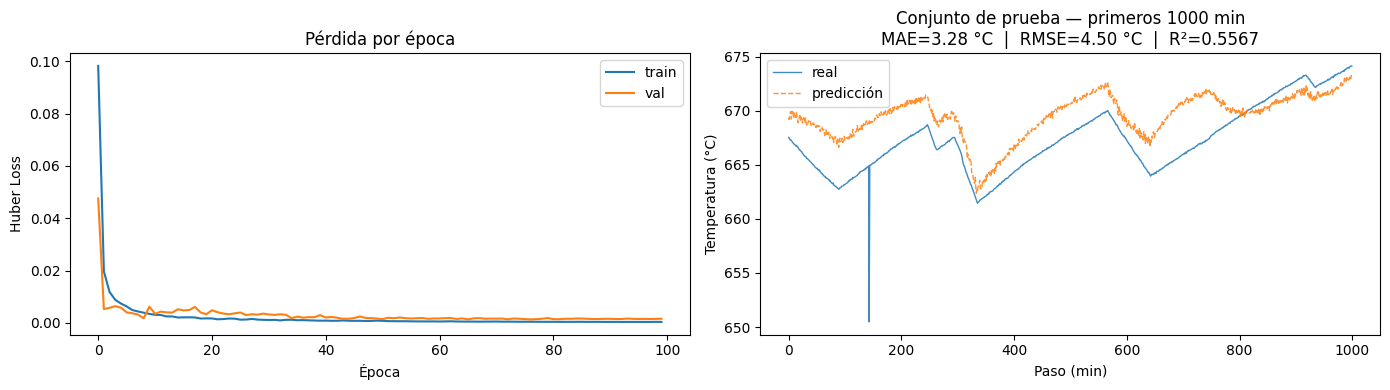


── G(z) via ajuste ARX (linealización en punto de operación) ──
  B (numerador)   = [-0.00601198 -0.00601198 -0.00601198]
  A (denominador) = [ 1.         -1.27556184 -0.33662589  0.92619478 -0.29888397]
  Válida cerca de: T≈683.0 °C, heater≈65.5 %


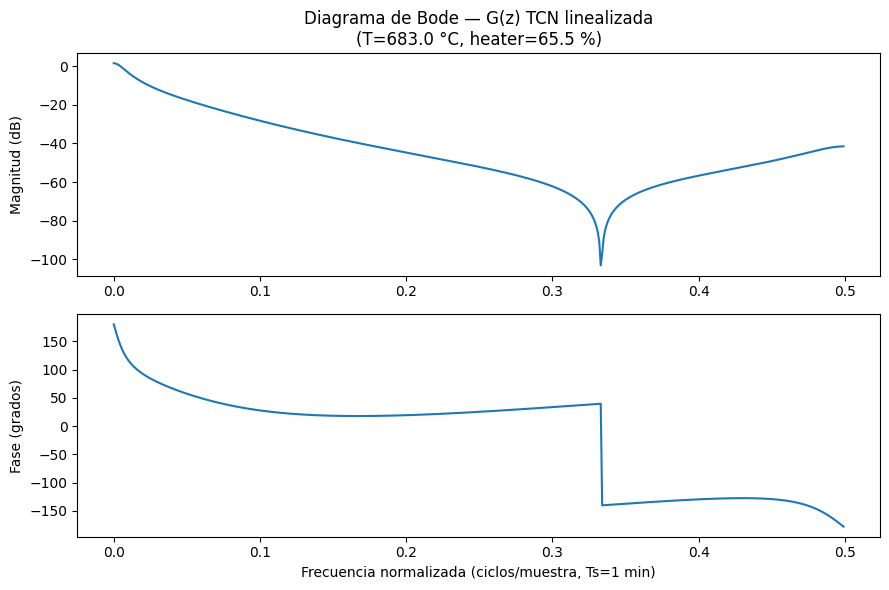

In [8]:
df = pd.read_csv(DATA_PATH)
model, scaler_X, scaler_y, history = train_pipeline(df, cfg)

# Punto de operación visto estable en EDA
op_point = {
    "heater_power_pct":       65.5,
    "resistance_current":     71.35,
    "voltage":               440.0,
    "aluminum_level_pct":     76.6,
    "lid_opening_pct":         3.0,
    "ambient_temp":           20.0,
    "energy_consumption_kwh":  0.87,
    "production_draw_rate":    0.0,
    "target_lag1":           683.0,
}

h, A, B = extract_gz(model, scaler_X, scaler_y, op_point, cfg)

## 9. Comparación de Funciones de Transferencia

In [9]:
def print_fraction(title, num_str, den_str):
    bar   = "─" * max(len(num_str), len(den_str))
    pad_n = (len(bar) - len(num_str)) // 2
    pad_d = (len(bar) - len(den_str)) // 2
    print(f"\n{'─'*10} {title} {'─'*10}")
    print(f"       {' '*pad_n}{num_str}")
    print(f" G(z) = {bar}")
    print(f"       {' '*pad_d}{den_str}")


def poly_str(coeffs, var='z', start_power=None):
    n = len(coeffs)
    if start_power is None: start_power = n - 1
    terms = []
    for i, c in enumerate(coeffs):
        power = start_power - i
        if abs(c) < 1e-10: continue
        sign = "+" if c >= 0 else "-"
        val  = f"{abs(c):.5f}"
        if power == 0:   terms.append(f"{sign} {val}")
        elif power == 1: terms.append(f"{sign} {val}{var}")
        else:            terms.append(f"{sign} {val}{var}^{power}")
    result = " ".join(terms).strip()
    return result[2:] if result.startswith("+ ") else result


print_fraction("modelo a/b  (ARX)", poly_str(B, start_power=len(B)-1),
                                     poly_str(A, start_power=len(A)-1))

print("\n" + "─"*10 + " referencia clásica (continuo) " + "─"*10)
print("         -627.125s + 7.25")
print(" G(s) = ─────────────────────────────────")
print("        186840s² + 2246.5s + 1")


────────── modelo a/b  (ARX) ──────────
                   - 0.00601z^2 - 0.00601z - 0.00601
 G(z) = ─────────────────────────────────────────────────────────
       1.00000z^4 - 1.27556z^3 - 0.33663z^2 + 0.92619z - 0.29888

────────── referencia clásica (continuo) ──────────
         -627.125s + 7.25
 G(s) = ─────────────────────────────────
        186840s² + 2246.5s + 1
